In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
import warnings

# Import the data processor
import sys
sys.path.append('../src')
from data_processor import DataProcessor

# Set visualization style
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create figure settings for better visualization
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

In [2]:
# Initialize DataProcessor
data_processor = DataProcessor()

# Load the dataset
file_path = "MachineLearningRating_v3.txt"
data = data_processor.load_data(file_path, parse_dates=["TransactionMonth"], sep='|')

# Display basic information about the loaded data
print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print(f"Data types:\n{data.dtypes}")
print(f"\nFirst few rows:")
print(data.head())

2025-08-24 00:13:39,647 - data_processor - INFO - Loading data from ../data\MachineLearningRating_v3.txt
2025-08-24 00:13:46,767 - data_processor - INFO - Successfully loaded data with shape (1000098, 52)


Data shape: (1000098, 52)
Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']
Data types:
UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[ns]
IsVATRegistered       

In [3]:
# Data Summarization and Descriptive Statistics
print("=== DATA SUMMARIZATION ===")
print(f"Dataset Shape: {data.shape}")
print(f"Date Range: {data['TransactionMonth'].min()} to {data['TransactionMonth'].max()}")
print(f"Total Records: {len(data):,}")
print(f"Unique Policies: {data['PolicyID'].nunique():,}")
print(f"Unique Provinces: {data['Province'].nunique()}")

# Calculate Loss Ratio (TotalClaims / TotalPremium)
data['LossRatio'] = data['TotalClaims'] / data['TotalPremium'].replace(0, np.nan)
print(f"\n=== LOSS RATIO ANALYSIS ===")
print(f"Overall Portfolio Loss Ratio: {data['LossRatio'].mean():.4f}")

# Descriptive Statistics for Key Financial Variables
print(f"\n=== DESCRIPTIVE STATISTICS ===")
financial_cols = ['TotalPremium', 'TotalClaims', 'SumInsured', 'CustomValueEstimate']
print(data[financial_cols].describe())

# Calculate variability (Coefficient of Variation)
print(f"\n=== VARIABILITY ANALYSIS ===")
for col in financial_cols:
    mean_val = data[col].mean()
    std_val = data[col].std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    print(f"{col}: CV = {cv:.4f}")

=== DATA SUMMARIZATION ===
Dataset Shape: (1000098, 52)
Date Range: 2013-10-01 00:00:00 to 2015-08-01 00:00:00
Total Records: 1,000,098
Unique Policies: 7,000
Unique Provinces: 9

=== LOSS RATIO ANALYSIS ===
Overall Portfolio Loss Ratio: 0.3499

=== DESCRIPTIVE STATISTICS ===
       TotalPremium  TotalClaims  SumInsured  CustomValueEstimate
count    1000098.00   1000098.00  1000098.00            220456.00
mean          61.91        64.86   604172.73            225531.13
std          230.28      2384.07  1508331.84            564515.75
min         -782.58    -12002.41        0.01             20000.00
25%            0.00         0.00     5000.00            135000.00
50%            2.18         0.00     7500.00            220000.00
75%           21.93         0.00   250000.00            280000.00
max        65282.60    393092.11 12636200.00          26550000.00

=== VARIABILITY ANALYSIS ===
TotalPremium: CV = 3.7199
TotalClaims: CV = 36.7566
SumInsured: CV = 2.4965
CustomValueEstimate: CV

In [4]:
# Data Quality Assessment
print("=== DATA QUALITY ASSESSMENT ===")

# Checking for missing values
missing_data = data.isnull().sum()
missing_percentage = (missing_data / len(data)) * 100
missing_summary = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Percentage', ascending=False)

print("Missing Values Summary:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

# Data Types Review
print(f"\n=== DATA TYPES REVIEW ===")
print("Current Data Types:")
print(data.dtypes)

# Check for mixed data types in object columns
print(f"\n=== MIXED DATA TYPE CHECK ===")
for col in data.columns:
    if data[col].dtype == 'object':
        unique_types = data[col].apply(type).value_counts()
        if len(unique_types) > 1:
            print(f"Column '{col}' has mixed types: {unique_types}")

=== DATA QUALITY ASSESSMENT ===
Missing Values Summary:
                         Missing_Count  Missing_Percentage
NumberOfVehiclesInFleet        1000098              100.00
CrossBorder                     999400               99.93
CustomValueEstimate             779642               77.96
WrittenOff                      641901               64.18
Converted                       641901               64.18
Rebuilt                         641901               64.18
LossRatio                       381634               38.16
NewVehicle                      153295               15.33
Bank                            145961               14.59
AccountType                      40232                4.02
Gender                            9536                0.95
MaritalStatus                     8259                0.83
VehicleIntroDate                   552                0.06
VehicleType                        552                0.06
Cylinders                          552                0.06


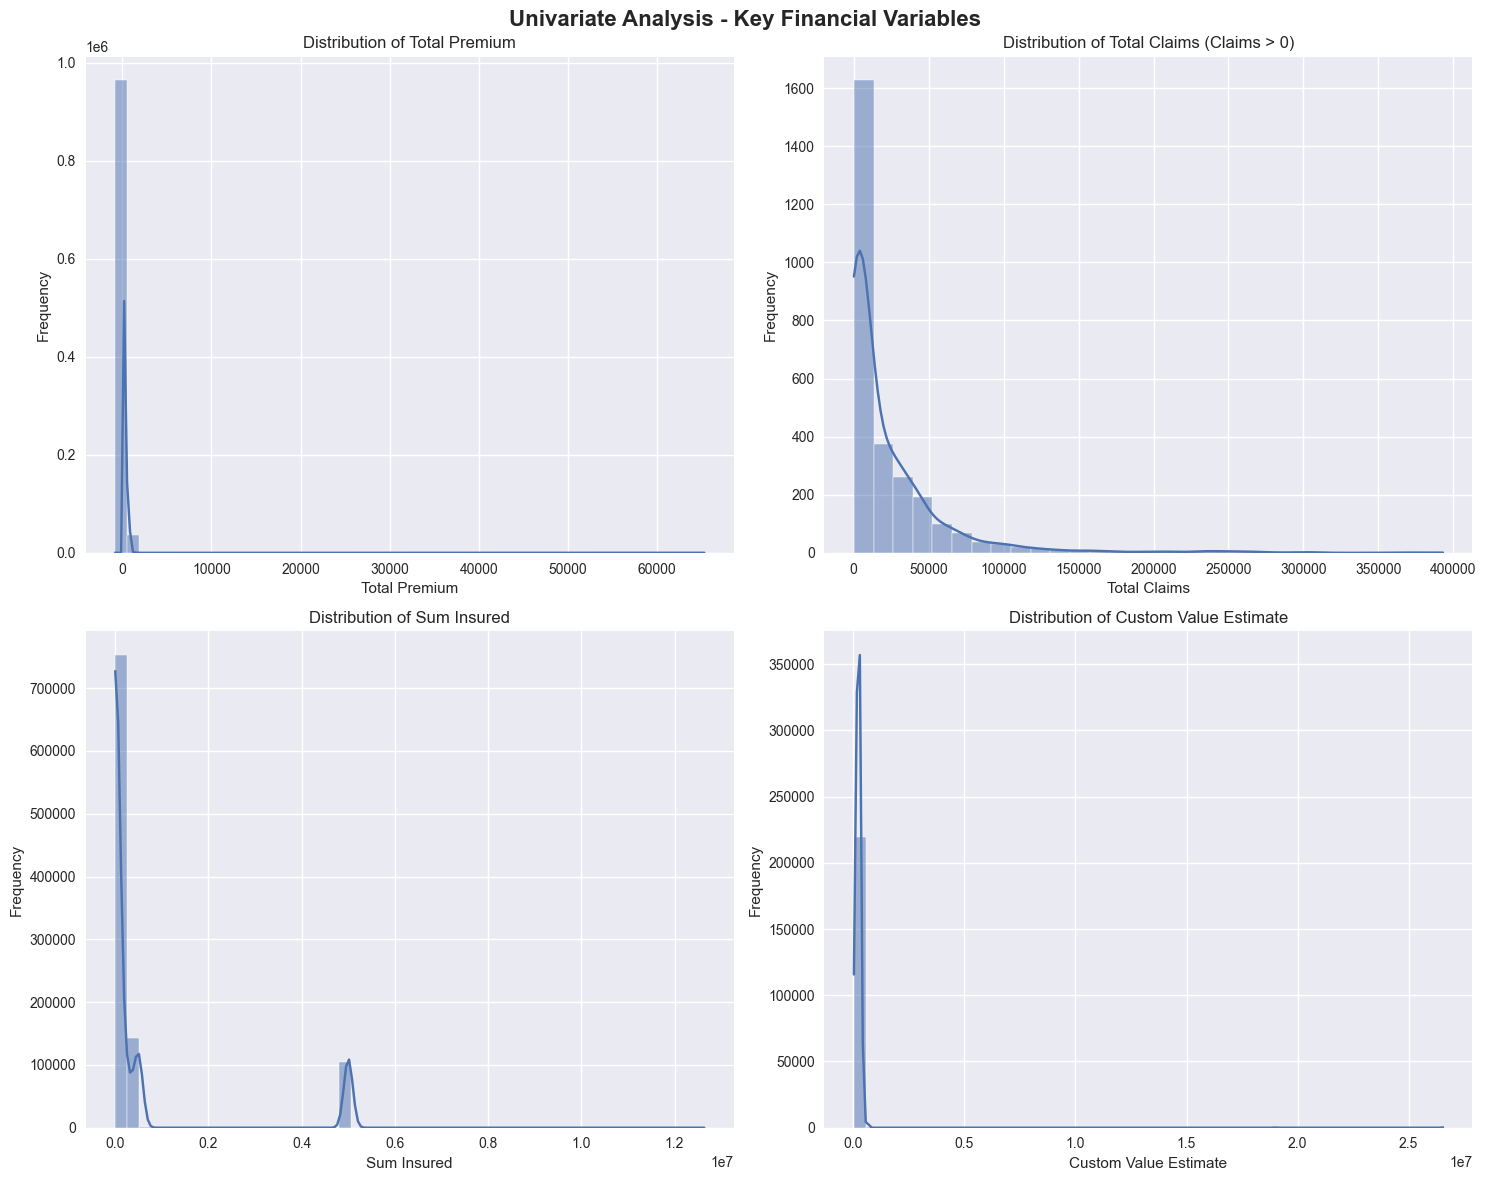

=== CATEGORICAL VARIABLES ANALYSIS ===

Province Distribution (Top 10):
Province
Gauteng          393865
Western Cape     170796
KwaZulu-Natal    169781
North West       143287
Mpumalanga        52718
Eastern Cape      30336
Limpopo           24836
Free State         8099
Northern Cape      6380
Name: count, dtype: int64

VehicleType Distribution (Top 10):
VehicleType
Passenger Vehicle    933598
Medium Commercial     53985
Heavy Commercial       7401
Light Commercial       3897
Bus                     665
Name: count, dtype: int64

Gender Distribution (Top 10):
Gender
Not specified    940990
Male              42817
Female             6755
Name: count, dtype: int64

CoverCategory Distribution (Top 10):
CoverCategory
Passenger Liability                        104158
Third Party                                102825
Keys and Alarms                            102428
Signage and Vehicle Wraps                  102416
Emergency Charges                          102416
Cleaning and Removal of A

In [6]:
# Univariate Analysis - Distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Univariate Analysis - Key Financial Variables', fontsize=16, fontweight='bold')

# 1. TotalPremium Distribution
sns.histplot(data=data, x='TotalPremium', bins=50, ax=axes[0,0], kde=True)
axes[0,0].set_title('Distribution of Total Premium')
axes[0,0].set_xlabel('Total Premium')
axes[0,0].set_ylabel('Frequency')

# 2. TotalClaims Distribution (log scale for better visualization)
claims_data = data[data['TotalClaims'] > 0]
if len(claims_data) > 0:
    sns.histplot(data=claims_data, x='TotalClaims', bins=30, ax=axes[0,1], kde=True)
    axes[0,1].set_title('Distribution of Total Claims (Claims > 0)')
    axes[0,1].set_xlabel('Total Claims')
    axes[0,1].set_ylabel('Frequency')

# 3. SumInsured Distribution
sns.histplot(data=data, x='SumInsured', bins=50, ax=axes[1,0], kde=True)
axes[1,0].set_title('Distribution of Sum Insured')
axes[1,0].set_xlabel('Sum Insured')
axes[1,0].set_ylabel('Frequency')

# 4. CustomValueEstimate Distribution 
custom_value_data = data[data['CustomValueEstimate'].notna()]
sns.histplot(data=custom_value_data, x='CustomValueEstimate', bins=50, ax=axes[1,1], kde=True)
axes[1,1].set_title('Distribution of Custom Value Estimate')
axes[1,1].set_xlabel('Custom Value Estimate')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Categorical Variables Analysis
print("=== CATEGORICAL VARIABLES ANALYSIS ===")
categorical_cols = ['Province', 'VehicleType', 'Gender', 'CoverCategory']

for col in categorical_cols:
    if col in data.columns:
        print(f"\n{col} Distribution (Top 10):")
        print(data[col].value_counts().head(10))

=== BIVARIATE ANALYSIS ===


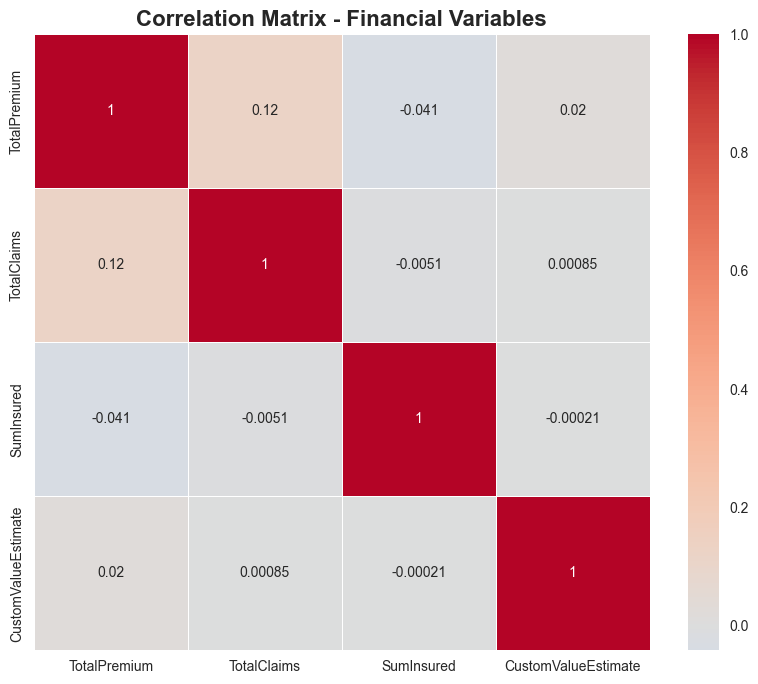

Loss Ratio by Province:
Province
Gauteng         0.43
Mpumalanga      0.39
Limpopo         0.35
Western Cape    0.34
North West      0.29
KwaZulu-Natal   0.26
Eastern Cape    0.24
Northern Cape   0.20
Free State      0.11
Name: LossRatio, dtype: float64

Loss Ratio by Vehicle Type:
VehicleType
Heavy Commercial    0.79
Light Commercial    0.54
Medium Commercial   0.49
Passenger Vehicle   0.34
Bus                 0.00
Name: LossRatio, dtype: float64


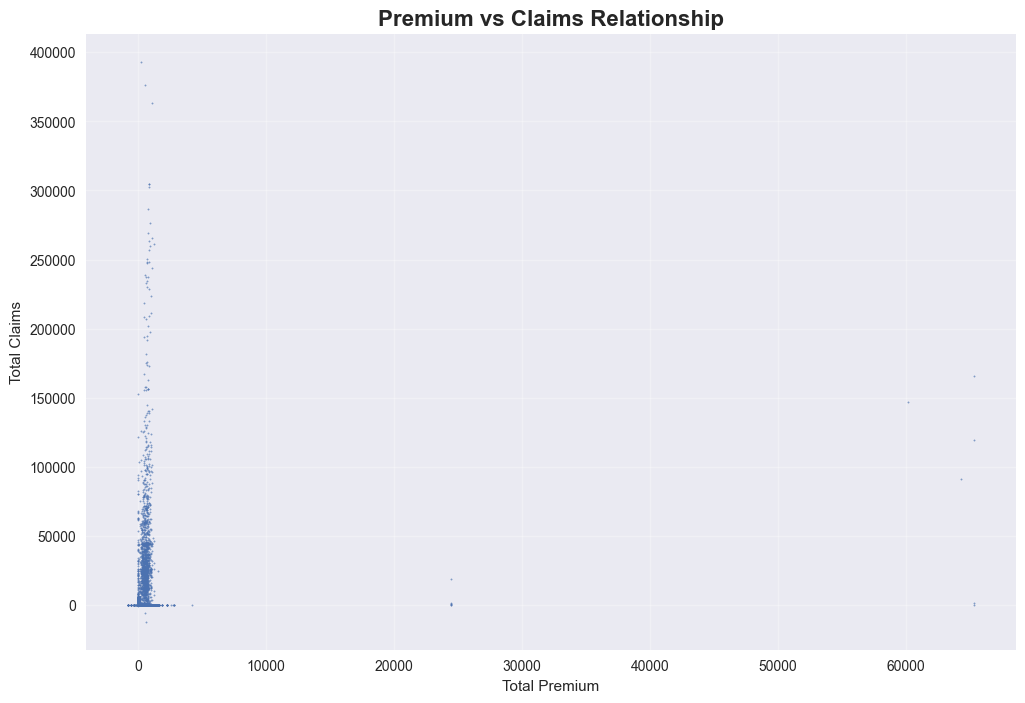

2025-08-24 00:25:05,438 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-24 00:25:05,440 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-24 00:25:05,443 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-24 00:25:05,445 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-24 00:25:05,

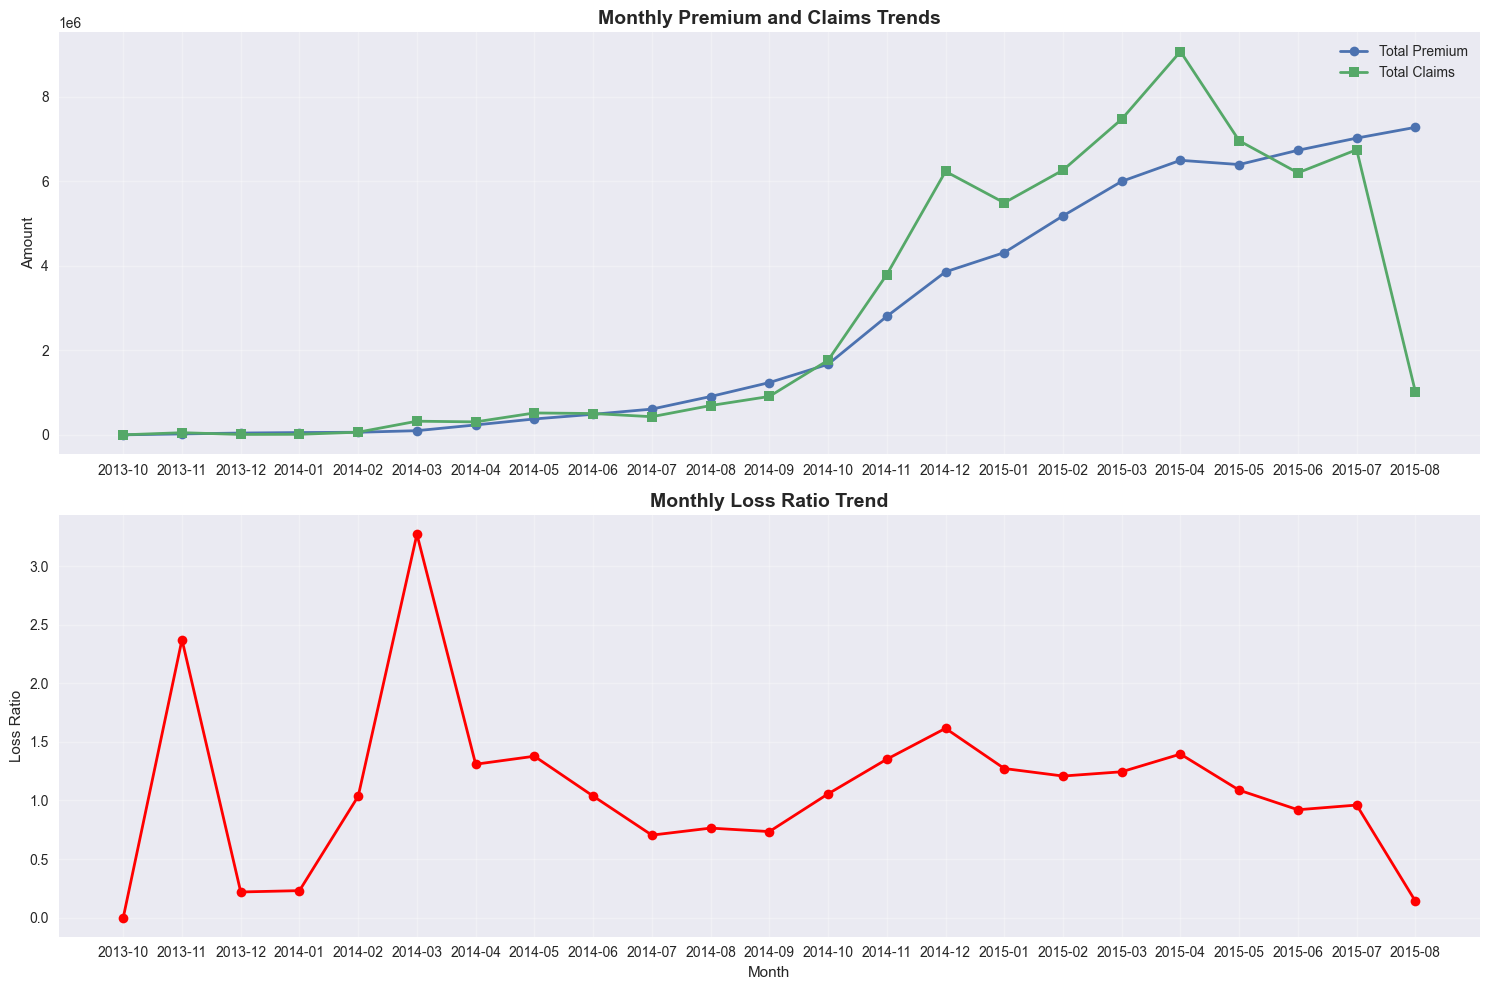

In [8]:
# Bivariate and Multivariate Analysis
print("=== BIVARIATE ANALYSIS ===")

# 1. Correlation Matrix for Financial Variables
financial_cols = ['TotalPremium', 'TotalClaims', 'SumInsured', 'CustomValueEstimate']
financial_data = data[financial_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(financial_data, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Financial Variables', fontsize=16, fontweight='bold')
plt.show()

# 2. Loss Ratio by Province and Vehicle Type
print("Loss Ratio by Province:")
province_loss = data.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
print(province_loss)

print(f"\nLoss Ratio by Vehicle Type:")
vehicle_loss = data.groupby('VehicleType')['LossRatio'].mean().sort_values(ascending=False)
print(vehicle_loss)

# 3. Scatter Plot: Premium vs Claims
plt.figure(figsize=(12, 8))
plt.scatter(data['TotalPremium'], data['TotalClaims'], alpha=0.6, s=1)
plt.xlabel('Total Premium')
plt.ylabel('Total Claims')
plt.title('Premium vs Claims Relationship', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Monthly Trends Analysis (Fixed)
monthly_trends = data.groupby(data['TransactionMonth'].dt.to_period('M')).agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum',
    'PolicyID': 'nunique'
}).reset_index()

monthly_trends['LossRatio'] = monthly_trends['TotalClaims'] / monthly_trends['TotalPremium']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Premium and Claims over time
ax1.plot(monthly_trends['TransactionMonth'].astype(str), monthly_trends['TotalPremium'], 
         marker='o', label='Total Premium', linewidth=2)
ax1.plot(monthly_trends['TransactionMonth'].astype(str), monthly_trends['TotalClaims'], 
         marker='s', label='Total Claims', linewidth=2)
ax1.set_title('Monthly Premium and Claims Trends', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amount')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss Ratio over time
ax2.plot(monthly_trends['TransactionMonth'].astype(str), monthly_trends['LossRatio'], 
         marker='o', color='red', linewidth=2)
ax2.set_title('Monthly Loss Ratio Trend', fontsize=14, fontweight='bold')
ax2.set_ylabel('Loss Ratio')
ax2.set_xlabel('Month')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== GEOGRAPHIC AND VEHICLE ANALYSIS ===
Loss Ratio by Province:
               mean   count
Province                   
Gauteng        0.43  240803
Mpumalanga     0.39   31663
Limpopo        0.35   18009
Western Cape   0.34   96775
North West     0.29   89799
KwaZulu-Natal  0.26  112142
Eastern Cape   0.24   19698
Northern Cape  0.20    3643
Free State     0.11    5932

Top 10 Vehicle Makes by Loss Ratio:
                                   make  TotalClaims  TotalPremium  PolicyID  \
40  SUZUKI                                 171210.89      27012.57         4   
22  JMC                                     23002.18       5635.79         1   
18                              HYUNDAI    453307.94     113615.56        29   
35                             POLARSUN    125197.84      41029.40        13   
26                            MARCOPOLO      7996.54       2665.65         1   
0                                  AUDI   1021003.71     376274.32        55   
2                              

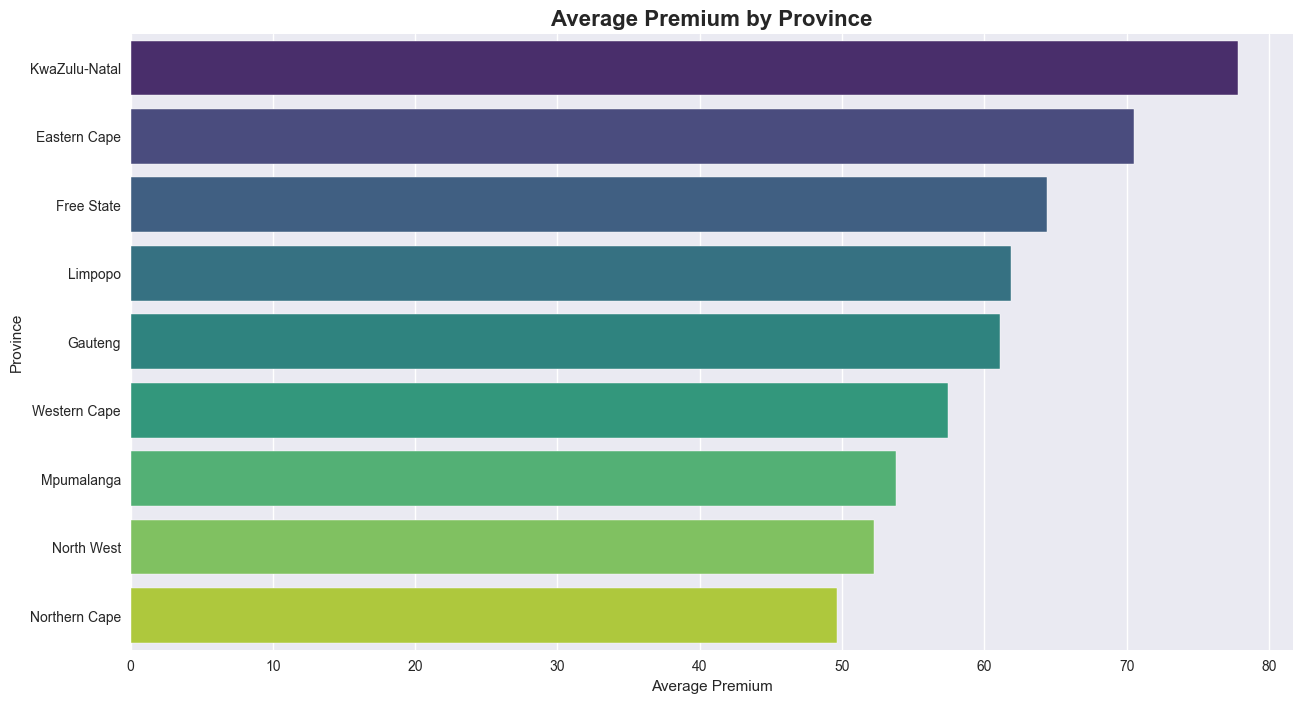

In [9]:
# Geographic and Vehicle Analysis
print("=== GEOGRAPHIC AND VEHICLE ANALYSIS ===")

# 1. Loss Ratio by Province
province_loss = data.groupby('Province')['LossRatio'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Loss Ratio by Province:")
print(province_loss)

# 2. Vehicle Make Analysis
vehicle_analysis = data.groupby('make').agg({
    'TotalClaims': 'sum',
    'TotalPremium': 'sum',
    'PolicyID': 'nunique'
}).reset_index()
vehicle_analysis['LossRatio'] = vehicle_analysis['TotalClaims'] / vehicle_analysis['TotalPremium']
vehicle_analysis['AvgPremium'] = vehicle_analysis['TotalPremium'] / vehicle_analysis['PolicyID']

print(f"\nTop 10 Vehicle Makes by Loss Ratio:")
print(vehicle_analysis.sort_values('LossRatio', ascending=False).head(10))

print(f"\nTop 10 Vehicle Makes by Average Premium:")
print(vehicle_analysis.sort_values('AvgPremium', ascending=False).head(10))

# 3. Geographic Premium Distribution
plt.figure(figsize=(15, 8))
province_premium = data.groupby('Province')['TotalPremium'].mean().sort_values(ascending=False)
sns.barplot(x=province_premium.values, y=province_premium.index, palette='viridis')
plt.title('Average Premium by Province', fontsize=16, fontweight='bold')
plt.xlabel('Average Premium')
plt.ylabel('Province')
plt.show()

=== OUTLIER DETECTION ===


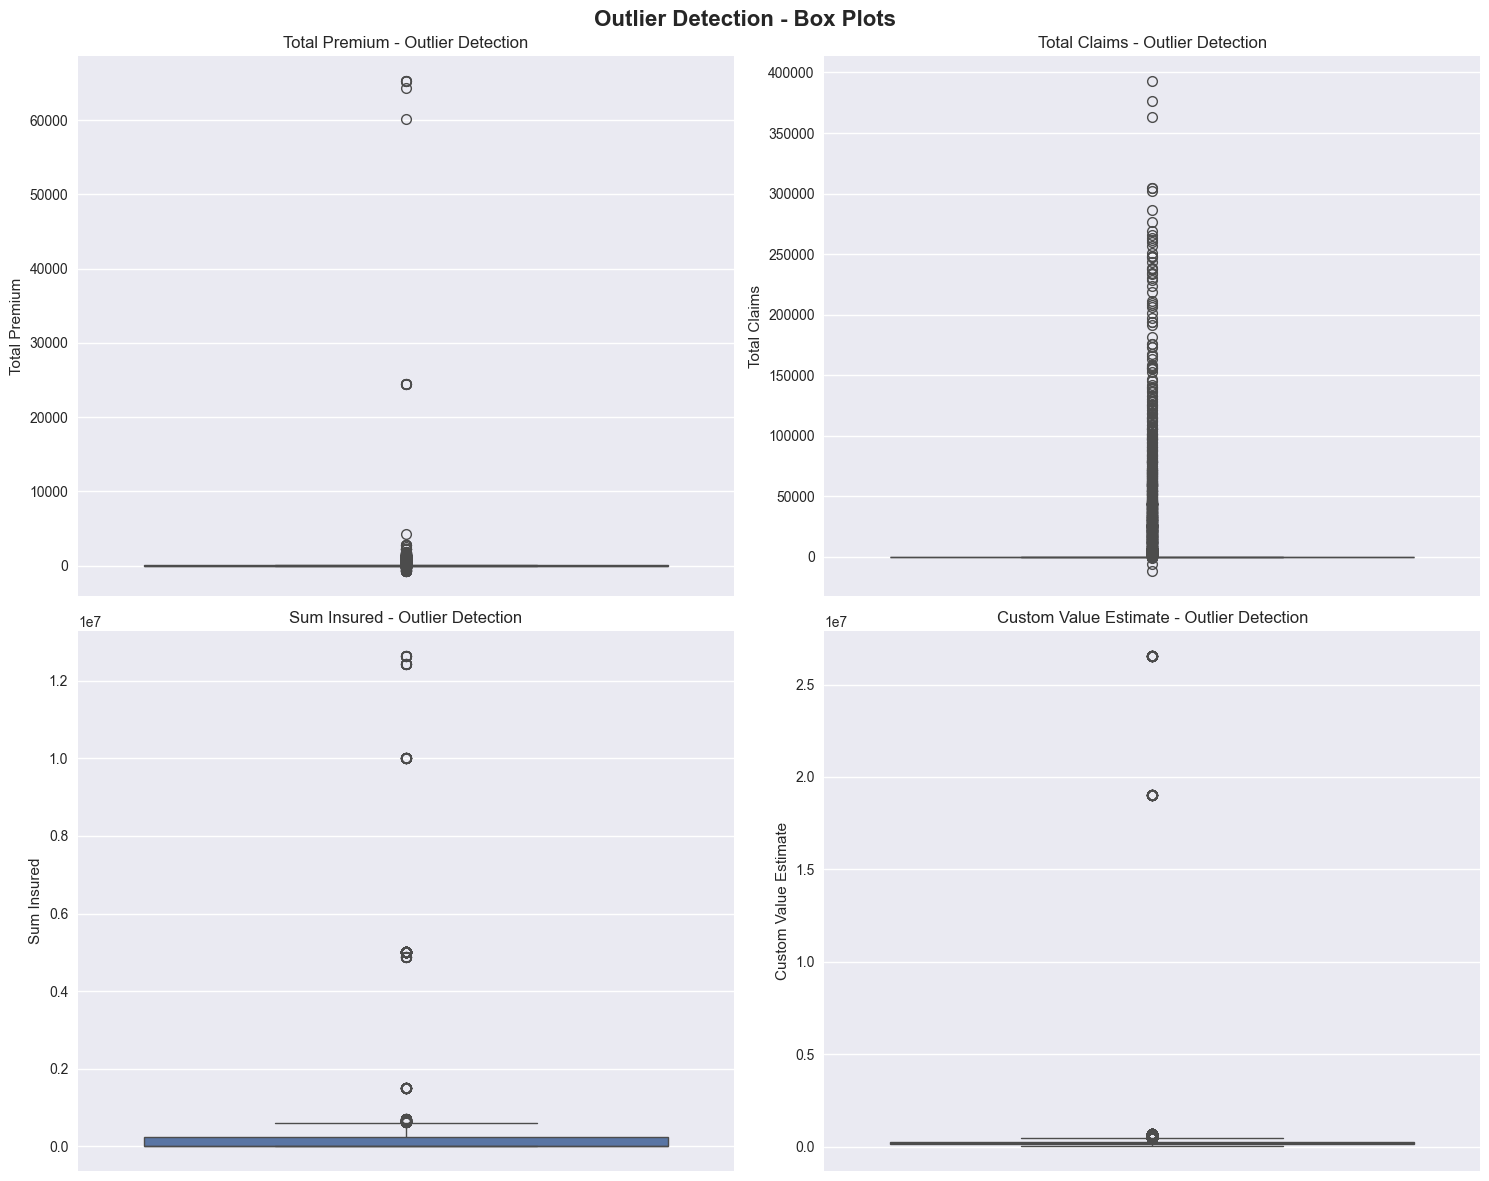

TotalPremium:
  Total outliers: 209042 (20.90%)
  Lower bound: -32.89
  Upper bound: 54.82

TotalClaims:
  Total outliers: 2793 (0.28%)
  Lower bound: 0.00
  Upper bound: 0.00

SumInsured:
  Total outliers: 104294 (10.43%)
  Lower bound: -362500.00
  Upper bound: 617500.00

CustomValueEstimate:
  Total outliers: 1785 (0.18%)
  Lower bound: -82500.00
  Upper bound: 497500.00



In [10]:
# Outlier Detection using Box Plots
print("=== OUTLIER DETECTION ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold')

# 1. TotalPremium Box Plot
sns.boxplot(data=data, y='TotalPremium', ax=axes[0,0])
axes[0,0].set_title('Total Premium - Outlier Detection')
axes[0,0].set_ylabel('Total Premium')

# 2. TotalClaims Box Plot
sns.boxplot(data=data, y='TotalClaims', ax=axes[0,1])
axes[0,1].set_title('Total Claims - Outlier Detection')
axes[0,1].set_ylabel('Total Claims')

# 3. SumInsured Box Plot
sns.boxplot(data=data, y='SumInsured', ax=axes[1,0])
axes[1,0].set_title('Sum Insured - Outlier Detection')
axes[1,0].set_ylabel('Sum Insured')

# 4. CustomValueEstimate Box Plot (only non-missing values)
custom_value_data = data[data['CustomValueEstimate'].notna()]
sns.boxplot(data=custom_value_data, y='CustomValueEstimate', ax=axes[1,1])
axes[1,1].set_title('Custom Value Estimate - Outlier Detection')
axes[1,1].set_ylabel('Custom Value Estimate')

plt.tight_layout()
plt.show()

# Statistical Outlier Detection using IQR method
def detect_outliers(series, column_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"{column_name}:")
    print(f"  Total outliers: {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print()

for col in financial_cols:
    detect_outliers(data[col], col)

=== CREATIVE VISUALIZATIONS & KEY INSIGHTS ===


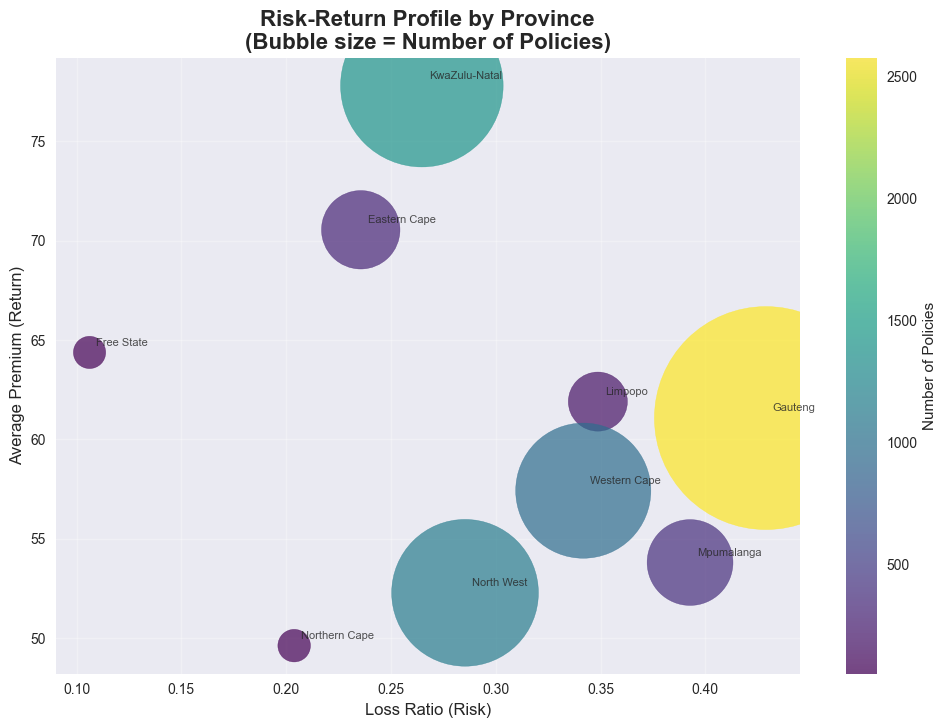

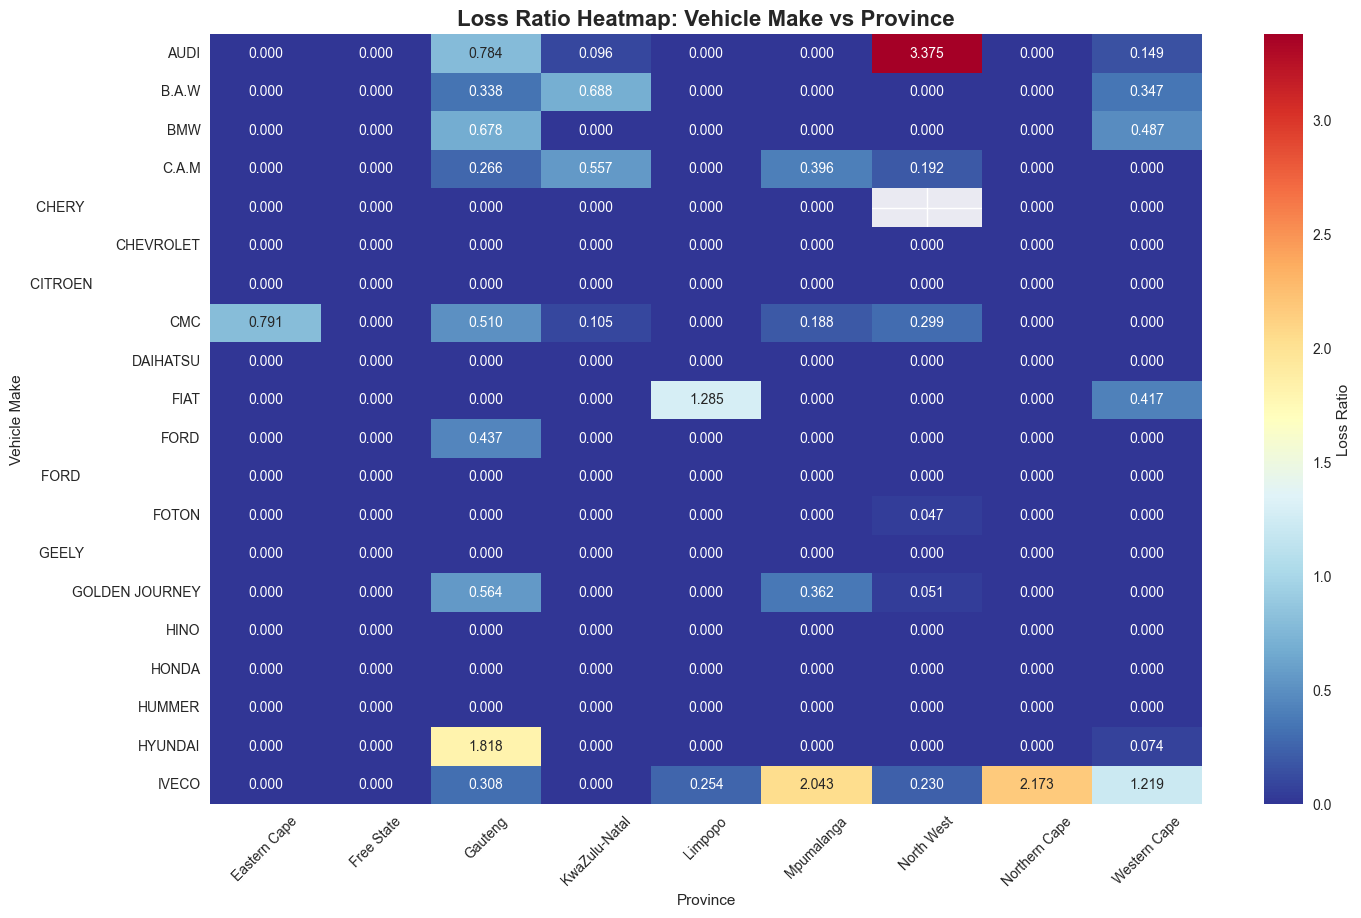

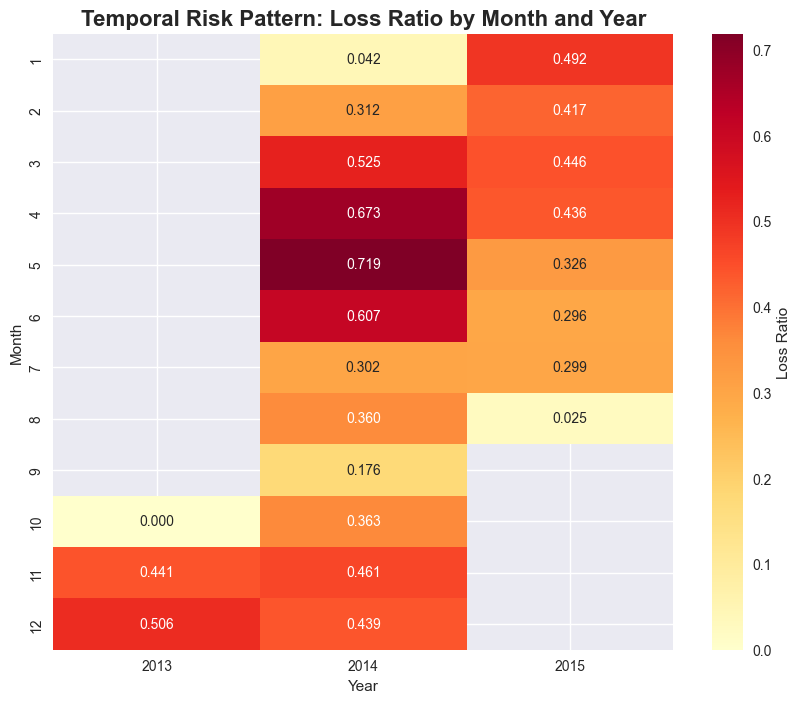

=== KEY INSIGHTS SUMMARY ===
1. Overall Portfolio Loss Ratio: 0.3499
2. Highest Risk Province: Gauteng
3. Highest Risk Vehicle Make: SUZUKI                             
4. Temporal Trend: Increasing
5. Geographic Risk Concentration: 4 provinces above average risk


In [13]:
# Creative Visualizations & Key Insights
print("=== CREATIVE VISUALIZATIONS & KEY INSIGHTS ===")

# 1. Risk-Return Profile by Province (Bubble Chart)
province_risk_return = data.groupby('Province').agg({
    'LossRatio': 'mean',
    'TotalPremium': 'mean',
    'PolicyID': 'nunique'
}).reset_index()

plt.figure(figsize=(12, 8))
scatter = plt.scatter(province_risk_return['LossRatio'], 
                     province_risk_return['TotalPremium'],
                     s=province_risk_return['PolicyID']*10, 
                     alpha=0.7, 
                     c=province_risk_return['PolicyID'],
                     cmap='viridis')

plt.xlabel('Loss Ratio (Risk)', fontsize=12)
plt.ylabel('Average Premium (Return)', fontsize=12)
plt.title('Risk-Return Profile by Province\n(Bubble size = Number of Policies)', 
          fontsize=16, fontweight='bold')

# Add province labels
for i, row in province_risk_return.iterrows():
    plt.annotate(row['Province'], 
                (row['LossRatio'], row['TotalPremium']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.colorbar(scatter, label='Number of Policies')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Vehicle Make Risk Analysis (Heatmap)
vehicle_province_risk = data.groupby(['make', 'Province'])['LossRatio'].mean().unstack(fill_value=0)

plt.figure(figsize=(16, 10))
sns.heatmap(vehicle_province_risk.head(20), 
            annot=True, fmt='.3f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Loss Ratio'})
plt.title('Loss Ratio Heatmap: Vehicle Make vs Province', fontsize=16, fontweight='bold')
plt.xlabel('Province')
plt.ylabel('Vehicle Make')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# 3. Temporal Risk Pattern (Calendar Heatmap) 
# Extract year and month separately
data['Year'] = data['TransactionMonth'].dt.year
data['Month'] = data['TransactionMonth'].dt.month

monthly_risk = data.groupby(['Year', 'Month'])['LossRatio'].mean().reset_index()

# Create pivot table for heatmap
risk_pivot = monthly_risk.pivot(index='Month', columns='Year', values='LossRatio')

plt.figure(figsize=(10, 8))
sns.heatmap(risk_pivot, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Loss Ratio'})
plt.title('Temporal Risk Pattern: Loss Ratio by Month and Year', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

# Summary of Key Insights
print("=== KEY INSIGHTS SUMMARY ===")
print("1. Overall Portfolio Loss Ratio:", f"{data['LossRatio'].mean():.4f}")
print("2. Highest Risk Province:", province_loss.index[0])
print("3. Highest Risk Vehicle Make:", vehicle_analysis.sort_values('LossRatio', ascending=False).iloc[0]['make'])
print("4. Temporal Trend:", "Increasing" if monthly_trends['LossRatio'].iloc[-1] > monthly_trends['LossRatio'].iloc[0] else "Decreasing")
print("5. Geographic Risk Concentration:", f"{len(province_loss[province_loss['mean'] > province_loss['mean'].mean()])} provinces above average risk")

In [14]:
!where python


c:\Users\aweso\AppData\Local\Programs\Python\Python312\python.exe
C:\Python313\python.exe
C:\msys64\ucrt64\bin\python.exe
C:\Users\aweso\AppData\Local\Microsoft\WindowsApps\python.exe
